# Numerical methods: geometric Asian control variates and continuous barriers

Build the extension in the project virtual environment and select its Python kernel. The Asian observation dates here are fixed at quarterly intervals; simulation steps and contractual observation frequency are separate. Continuous barriers use GBM Brownian bridge conditional crossing weights.

All comparisons record the path count, seed, parameters and elapsed time. Confidence intervals reflect sampling uncertainty.

module: 0.1.0
engine: McEngine(paths=12000, seed=42, antithetic=true, parallel=true)
model: {'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252} Asian dates: [63, 126, 189, 252]
Geometric analytic: 7.364108672842035
Controlled Greeks: Greeks(delta=0.568156, gamma=0.022909, vega=26.501687, theta=4.172020, rho=28.515650)
none PriceResult(price=7.647459, std_error=0.080476, samples=6000, ci95=[7.489730, 7.805189]) SE reduction: 1.0
european PriceResult(price=7.636937, std_error=0.045295, samples=6000, ci95=[7.548160, 7.725714]) SE reduction: 1.77669722347273
geometric PriceResult(price=7.648828, std_error=0.003817, samples=6000, ci95=[7.641346, 7.656310]) SE reduction: 21.08112220057779


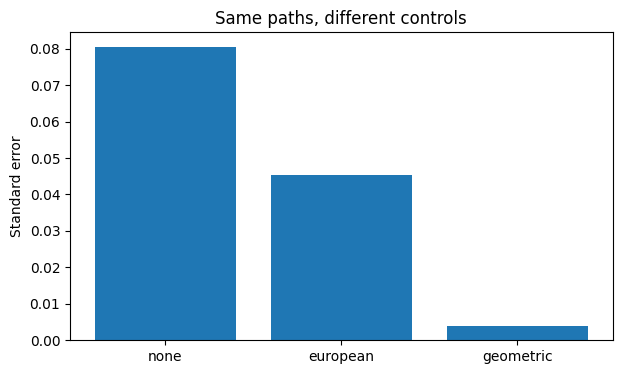

In [1]:
import math
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import fuzzy_enigma as fe

PATHS, SEED = 12_000, 42
engine = fe.McEngine(paths=PATHS, seed=SEED, antithetic=True, parallel=True)
records = []

def timed(label, call, **parameters):
    start = perf_counter()
    result = call()
    record = dict(label=label, price=result.price, std_error=result.std_error,
                  samples=result.samples, ci95=result.confidence_95(),
                  elapsed_s=perf_counter()-start, paths=PATHS, seed=SEED,
                  parameters=parameters)
    records.append(record)
    return result

print('module:', fe.__version__)
print('engine:', engine)

base = dict(spot=100.0, r=0.03, q=0.0, sigma=0.25, t=1.0, steps=252)
model = fe.GbmModel(**base)
dates = [63, 126, 189, 252]
print('model:', base, 'Asian dates:', dates)
results = {kind: timed('Asian '+kind, lambda kind=kind: engine.price_asian_scheduled(
    model, 'call', 100.0, dates, control=kind), **base, strike=100.0, control=kind, dates=dates)
    for kind in ('none', 'european', 'geometric')}
print('Geometric analytic:', fe.geometric_asian_price(model, 'call', 100.0, dates))
print('Controlled Greeks:', engine.greeks_asian_scheduled(model, 'call', 100.0, dates, control='geometric'))
for kind, result in results.items():
    print(kind, result, 'SE reduction:', results['none'].std_error/result.std_error)
assert results['geometric'].std_error < results['none'].std_error
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(results), [r.std_error for r in results.values()])
ax.set(ylabel='Standard error', title='Same paths, different controls')
plt.show()


## Path counts and standard errors

Change only the path count, keeping the model and schedule fixed. For a given seed, the runs share the initial portion of the random stream; the curves compare the effects of variance reduction.

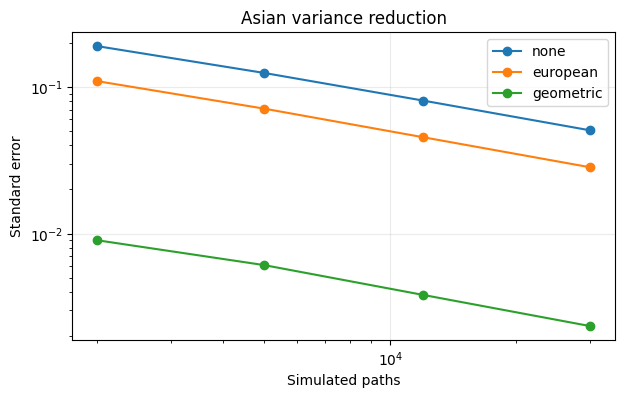

In [2]:
counts = [2_000, 5_000, 12_000, 30_000]
errors = {kind: [] for kind in results}
for count in counts:
    e = fe.McEngine(paths=count, seed=SEED, antithetic=True, parallel=True)
    for kind in errors:
        start = perf_counter()
        result = e.price_asian_scheduled(model, 'call', 100.0, dates, control=kind)
        errors[kind].append(result.std_error)
        records.append(dict(label='Asian convergence '+kind, price=result.price,
            std_error=result.std_error, samples=result.samples, ci95=result.confidence_95(),
            elapsed_s=perf_counter()-start, paths=count, seed=SEED,
            parameters={**base, 'strike': 100.0, 'control': kind, 'dates': dates}))
fig, ax = plt.subplots(figsize=(7, 4))
for kind, ys in errors.items(): ax.loglog(counts, ys, 'o-', label=kind)
ax.set(xlabel='Simulated paths', ylabel='Standard error', title='Asian variance reduction')
ax.grid(alpha=0.25); ax.legend(); plt.show()


## Continuous and discrete barriers

Fix S0=K=100 and the upper barrier at 130. Increasing the number of simulation steps refines the discretely monitored contract. The Brownian bridge method always represents the same continuously monitored contract, integrating crossing probabilities between grid points even on a coarse grid.

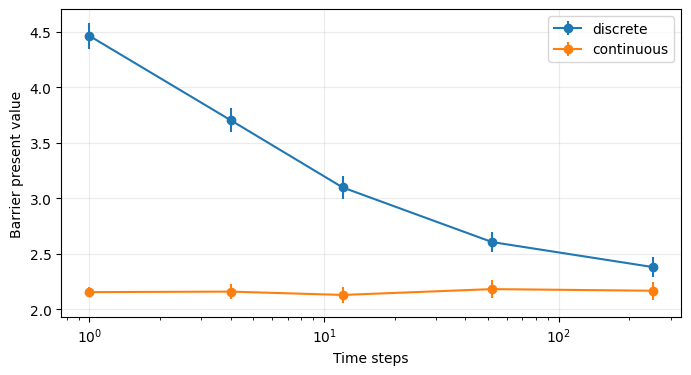

Continuous Greeks: Greeks(delta=0.018183, gamma=0.025406, vega=-15.156461, theta=-1.754544, rho=4.404733)


In [3]:
grids = [1, 4, 12, 52, 252]
barrier_results = {'discrete': [], 'continuous': []}
for steps in grids:
    params = {**base, 'steps': steps}
    m = fe.GbmModel(**params)
    discrete = timed('Discrete barrier', lambda: engine.price_barrier(m, 'call', 'up_and_out', 100.0, 130.0),
                     **params, strike=100.0, barrier=130.0, rebate=0.0)
    continuous = timed('Continuous barrier', lambda: engine.price_continuous_barrier(m, 'call', 'up_and_out', 100.0, 130.0),
                       **params, strike=100.0, barrier=130.0, rebate=0.0)
    barrier_results['discrete'].append(discrete)
    barrier_results['continuous'].append(continuous)
    assert continuous.price <= discrete.price + 1e-10
fig, ax = plt.subplots(figsize=(8, 4))
for kind, rs in barrier_results.items():
    ax.errorbar(grids, [r.price for r in rs], yerr=[1.96*r.std_error for r in rs], fmt='o-', label=kind)
ax.set(xscale='log', xlabel='Time steps', ylabel='Barrier present value')
ax.grid(alpha=0.25); ax.legend(); plt.show()
print('Continuous Greeks:', engine.greeks_continuous_barrier(model, 'call', 'up_and_out', 100.0, 130.0))


In [4]:
for row in records:
    print(f"{row['label']:<28} price={row['price']:9.5f} SE={row['std_error']:.5f} "
          f"elapsed={row['elapsed_s']:.3f}s paths={row['paths']} seed={row['seed']} "
          f"params={row['parameters']}")


Asian none                   price=  7.64746 SE=0.08048 elapsed=0.011s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'strike': 100.0, 'control': 'none', 'dates': [63, 126, 189, 252]}
Asian european               price=  7.63694 SE=0.04530 elapsed=0.010s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'strike': 100.0, 'control': 'european', 'dates': [63, 126, 189, 252]}
Asian geometric              price=  7.64883 SE=0.00382 elapsed=0.009s paths=12000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'strike': 100.0, 'control': 'geometric', 'dates': [63, 126, 189, 252]}
Asian convergence none       price=  7.53936 SE=0.18925 elapsed=0.003s paths=2000 seed=42 params={'spot': 100.0, 'r': 0.03, 'q': 0.0, 'sigma': 0.25, 't': 1.0, 'steps': 252, 'strike': 100.0, 'control': 'none', 'dates': [63, 126, 189, 252]}
Asian convergence european   pri